C:\Users\eddaoudi\AppData\Local\Temp\ipykernel_4472\2150936288.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_topic['class_en'] = df_topic['class'].map(label_translation)
C:\Users\eddaoudi\AppData\Local\Temp\ipykernel_4472\2150936288.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')


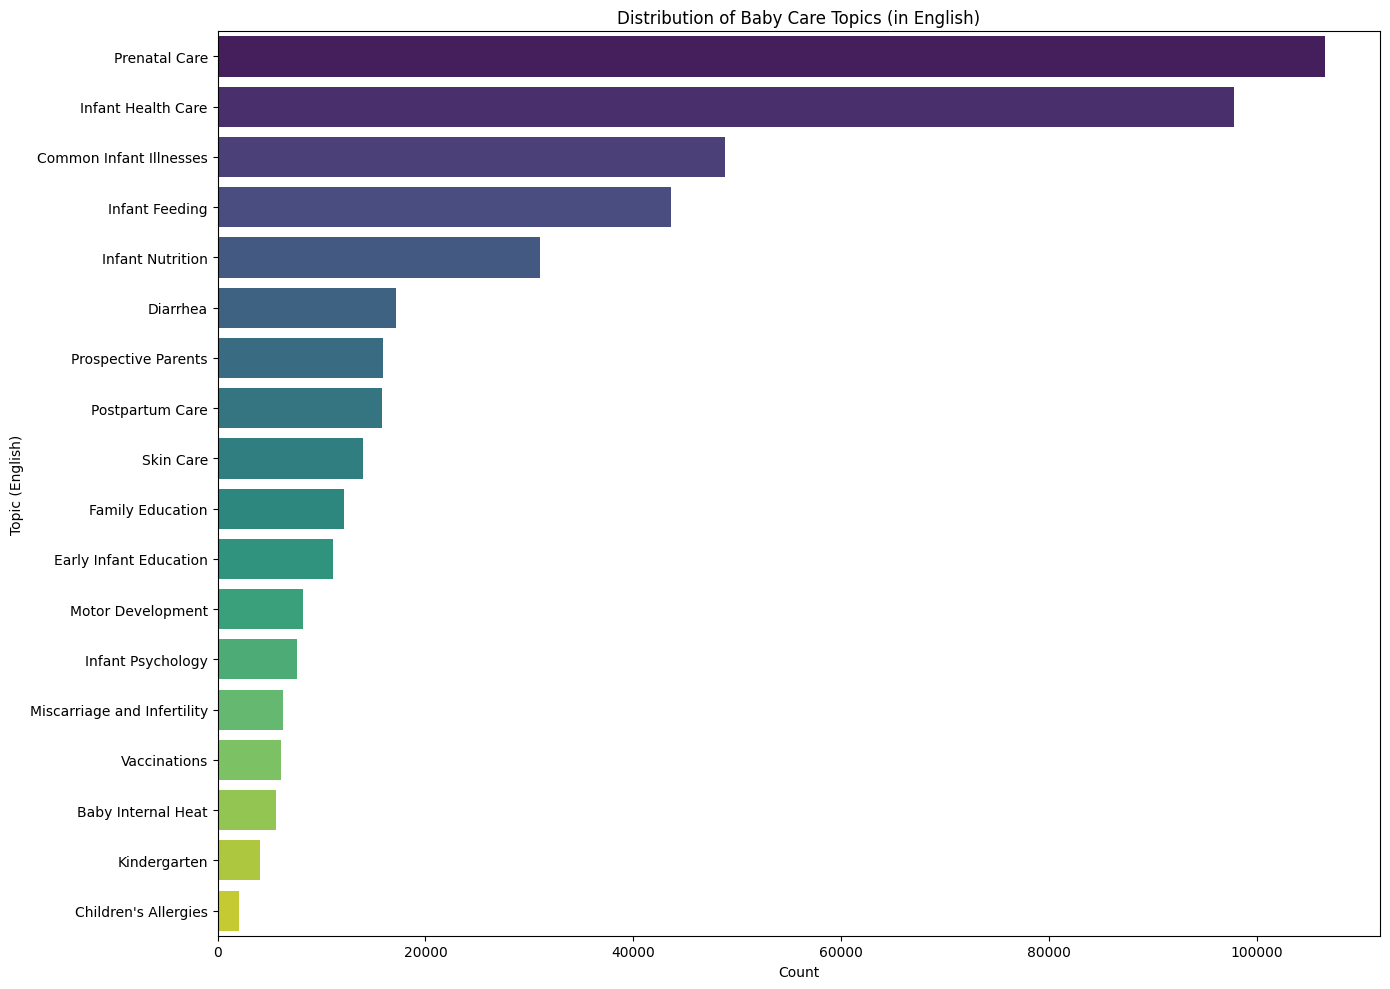

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Load data
df = pd.read_csv('../Data/train.csv')

# Map Chinese labels to English
label_translation = {
    '孕期保健': 'Prenatal Care',
    '婴幼保健': 'Infant Health Care',
    '0-1岁': '0-1 Year Old',
    '婴幼常见病': 'Common Infant Illnesses',
    '婴幼期喂养': 'Infant Feeding',
    '婴幼营养': 'Infant Nutrition',
    '1-2岁': '1-2 Years Old',
    '腹泻': 'Diarrhea',
    '未准父母': 'Prospective Parents',
    '产褥期保健': 'Postpartum Care',
    '皮肤护理': 'Skin Care',
    '家庭教育': 'Family Education',
    '2-3岁': '2-3 Years Old',
    '婴幼早教': 'Early Infant Education',
    '动作发育': 'Motor Development',
    '婴幼心理': 'Infant Psychology',
    '流产和不孕': 'Miscarriage and Infertility',
    '疫苗接种': 'Vaccinations',
    '宝宝上火': 'Baby Internal Heat',
    '幼儿园': 'Kindergarten',
    '儿童过敏': 'Children\'s Allergies'
}

# Filter out age-based classes
df_topic = df[~df['class'].isin(['0-1岁', '1-2岁', '2-3岁'])]

# Translate class names to English
df_topic['class_en'] = df_topic['class'].map(label_translation)

# Count values for English classes
class_counts = df_topic['class_en'].value_counts()

# Plot
plt.figure(figsize=(14, 10))
sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')
plt.xlabel('Count')
plt.ylabel('Topic (English)')
plt.title('Distribution of Baby Care Topics (in English)')
plt.tight_layout()
plt.show()


In [4]:
# Filter age groups and make a copy to avoid warning
df_age_topic = df[df['class'].isin(['0-1岁', '1-2岁', '2-3岁'])].copy()

# Replace Chinese age labels with English
df_age_topic['class'] = df_age_topic['class'].replace({
    '0-1岁': '0-1 year',
    '1-2岁': '1-2 year',
    '2-3岁': '2-3 year'
})


C:\Users\eddaoudi\AppData\Local\Temp\ipykernel_4472\1029017995.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette='Set2')


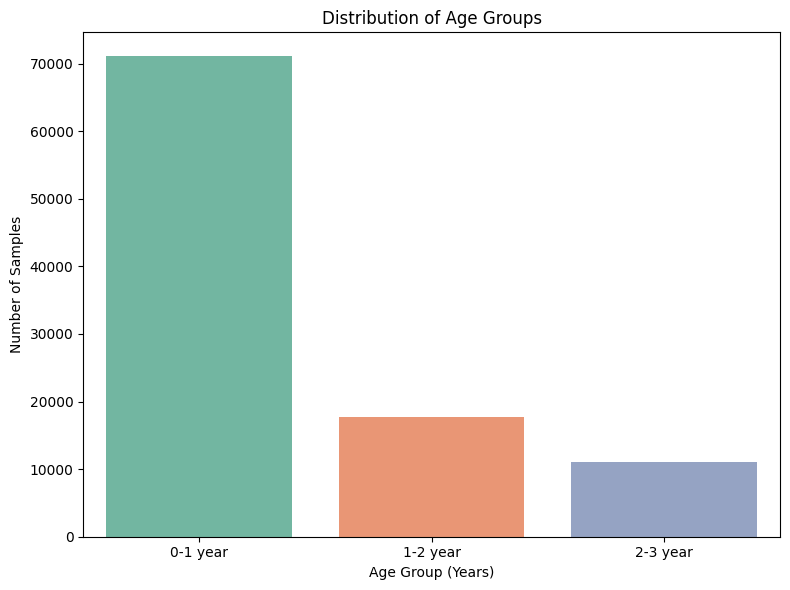

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of samples per age group
age_counts = df_age_topic['class'].value_counts().sort_index()

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x=age_counts.index, y=age_counts.values, palette='Set2')

plt.xlabel('Age Group (Years)')
plt.ylabel('Number of Samples')
plt.title('Distribution of Age Groups')
plt.tight_layout()
plt.show()
